In [1]:
import os

import time
import gc
import shutil
import tempfile
import threading
import subprocess
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED

import numpy as np
import cupy as cp
from numpy.lib.format import open_memmap

# ============================================================
# CONFIG
# ============================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"
DERIVED = os.path.join(BASE, "Derived_things")
SITE_DIR = os.path.join(BASE, "ERA5_DATABASE", "site_87603_771167")

# where all outputs go
OUTDIR = os.path.join(BASE, "amc_runtime_all_timesteps")
os.makedirs(OUTDIR, exist_ok=True)

AM_EXE = os.path.join(BASE, "am.exe")

# how many hours per chunk for profile construction
CHUNK_T = 50
CHECKPOINT_EVERY = 5

# how many AM processes to run at once
N_WORKERS = 8
MAX_RETRIES = 3
MAX_INFLIGHT = N_WORKERS * 4

# quantization steps
Pstep, Tstep, Qstep = 50.0, 1, 2e-4

# if False, only these frequencies are stored in the spectrum tables
# if True, the full AM spectrum is stored
SAVE_FULL_SPECTRUM = False
TARGET_FREQS_GHZ = [2.0, 14.0]

# ============================================================
# LOAD INPUTS
# ============================================================

try:
    meta
except NameError:
    meta = np.load(os.path.join(SITE_DIR, "metadata_pressure.npz"))

insert_idx  = np.load(os.path.join(DERIVED, "insert_idx.npy"))      # (T,H,W)
p_surface   = np.load(os.path.join(DERIVED, "ps.npy"))              # (T,H,W)
t_surface   = np.load(os.path.join(DERIVED, "ts.npy"))              # (T,H,W)
vmr_surface = np.load(os.path.join(DERIVED, "vmr_surface.npy"))     # (T,H,W)
temp        = np.load(os.path.join(DERIVED, "temp.npy"))            # (T,13)
vmr         = np.load(os.path.join(DERIVED, "vmr_q.npy"))           # (T,13)

levels_pa = cp.asarray(meta["pressure_levels"] * 100.0, dtype=cp.float32)  # (13,)

T, H, W = insert_idx.shape
n_levels = int(levels_pa.shape[0])     # 13
n_out = n_levels + 1                   # 14 after inserting surface
PROFILE_LEN = 1 + 3 * n_out           # [ins, P14, T14, Q14]

print(f"T={T}  H={H}  W={W}  levels={n_levels}")
print(f"Total pixel-timesteps: {T*H*W:,}")

# ============================================================
# PHASE 1: BUILD GLOBAL UNIQUE PROFILES
# ============================================================

global_unique = np.empty((0, PROFILE_LEN), dtype=np.float32)
pixel_to_profile = np.empty((T, H, W), dtype=np.int32)

k_arr_base = cp.arange(n_out, dtype=cp.int32).reshape(1, 1, 1, n_out)

def build_chunk_profiles(t0, t1):
    """
    Vectorized profile builder for timesteps [t0, t1).
    Returns a CPU ndarray of shape (Tc*H*W, PROFILE_LEN).
    """
    idx_c  = cp.asarray(insert_idx[t0:t1]).astype(cp.int32)          # (Tc,H,W)
    Ps_c   = cp.asarray(p_surface[t0:t1],   dtype=cp.float32)
    Ts_c   = cp.asarray(t_surface[t0:t1],   dtype=cp.float32)
    Qs_c   = cp.asarray(vmr_surface[t0:t1], dtype=cp.float32)
    Tera_c = cp.asarray(temp[t0:t1],        dtype=cp.float32)         # (Tc,13)
    Qera_c = cp.asarray(vmr[t0:t1],         dtype=cp.float32)         # (Tc,13)

    Tc = idx_c.shape[0]

    shift = (k_arr_base > idx_c[..., None]).astype(cp.int32)          # (Tc,H,W,14)
    src = cp.clip(k_arr_base - shift, 0, n_levels - 1)                # (Tc,H,W,14)

    t_idx4 = cp.arange(Tc, dtype=cp.int32).reshape(Tc, 1, 1, 1)

    P_prof = levels_pa[src]                                            # (Tc,H,W,14)
    T_prof = Tera_c[t_idx4, src]
    Q_prof = Qera_c[t_idx4, src]

    cp.put_along_axis(P_prof, idx_c[..., None], Ps_c[..., None], axis=3)
    cp.put_along_axis(T_prof, idx_c[..., None], Ts_c[..., None], axis=3)
    cp.put_along_axis(Q_prof, idx_c[..., None], Qs_c[..., None], axis=3)

    P_q = cp.round(P_prof / Pstep) * Pstep
    T_q = cp.round(T_prof / Tstep) * Tstep
    Q_q = cp.round(Q_prof / Qstep) * Qstep

    profiles = cp.concatenate(
        [idx_c[..., None].astype(cp.float32), P_q, T_q, Q_q],
        axis=-1
    )  # (Tc,H,W,PROFILE_LEN)

    return cp.asnumpy(profiles.reshape(-1, PROFILE_LEN))

print("\nPhase 1: building & globally deduplicating profiles...")
t_start = time.time()

for chunk_i, t0 in enumerate(range(0, T, CHUNK_T)):
    t1 = min(t0 + CHUNK_T, T)
    Tc = t1 - t0

    chunk_profiles = build_chunk_profiles(t0, t1)   # (Tc*H*W, PROFILE_LEN)

    n_old = global_unique.shape[0]
    stacked = np.vstack([global_unique, chunk_profiles])
    merged, inverse = np.unique(stacked, axis=0, return_inverse=True)

    if n_old > 0:
        old_to_new = inverse[:n_old]
        pixel_to_profile[:t0] = old_to_new[pixel_to_profile[:t0]]

    pixel_to_profile[t0:t1] = inverse[n_old:].reshape(Tc, H, W)
    global_unique = merged

    elapsed = time.time() - t_start
    print(
        f"chunk {chunk_i:4d}  t=[{t0}:{t1})  "
        f"unique so far: {len(global_unique):8d}  "
        f"elapsed: {elapsed/60:6.1f} min"
    )

    if (chunk_i + 1) % CHECKPOINT_EVERY == 0:
        np.save(os.path.join(OUTDIR, "global_unique_profiles.npy"), global_unique)
        np.save(os.path.join(OUTDIR, "pixel_to_profile.npy"), pixel_to_profile)

np.save(os.path.join(OUTDIR, "global_unique_profiles.npy"), global_unique)
np.save(os.path.join(OUTDIR, "pixel_to_profile.npy"), pixel_to_profile)

n_unique = len(global_unique)
print(f"\nDone. Total pixel-timesteps: {T*H*W:,}")
print(f"Globally unique atmospheres: {n_unique:,}")
print(f"Reduction factor: {T*H*W/n_unique:,.1f}x")

# ============================================================
# PHASE 2+3: RUN AM USING ONE TEMP FILE PER WORKER
# ============================================================

worker_state = threading.local()
worker_temp_dirs = set()
worker_temp_lock = threading.Lock()

def get_worker_amc_path():
    """
    One temp AMC file per worker thread, reused for all tasks on that thread.
    """
    if not hasattr(worker_state, "amc_path"):
        d = tempfile.mkdtemp(prefix="am_worker_", dir=OUTDIR)
        worker_state.temp_dir = d
        worker_state.amc_path = os.path.join(d, "temp.amc")
        with worker_temp_lock:
            worker_temp_dirs.add(d)
    return worker_state.amc_path

def profile_to_amc_text(prof):
    """
    Convert one unique profile row to AM input text.
    """
    ins = int(prof[0])
    P = prof[1 : 1 + n_out]
    Tt = prof[1 + n_out : 1 + 2 * n_out]
    Q = prof[1 + 2 * n_out : 1 + 3 * n_out]

    # only atmosphere above the surface, top -> bottom
    P_use = P[ins:]
    T_use = Tt[ins:]
    Q_use = Q[ins:]

    lines = []
    lines.append("f 2 GHz 14 GHz 0.01 GHz")
    lines.append("output f GHz tx Tb K")
    lines.append("T0 2.7 K")
    lines.append("za 0 deg")
    lines.append("")

    for p, t, q in zip(P_use[::-1], T_use[::-1], Q_use[::-1]):
        lines.append("layer")
        lines.append(f"Pbase {p:.1f} Pa")
        lines.append(f"Tbase {t:.6f} K")
        lines.append("column dry_air hydrostatic")
        lines.append(f"column h2o vmr {q:.10e}")
        lines.append("")

    return "\n".join(lines)

def run_am_for_profile(idx):
    """
    Run AM for global_unique[idx] using the caller thread's temp AMC file.
    Returns (idx, freq, tau, tb) or None.
    """
    amc_path = get_worker_amc_path()
    prof = global_unique[idx]
    amc_text = profile_to_amc_text(prof)

    with open(amc_path, "w", encoding="utf-8", newline="\n") as f:
        f.write(amc_text)

    result = subprocess.run(
        [AM_EXE, amc_path],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        encoding="utf-8",
        errors="ignore"
    )

    if result.returncode != 0:
        return None

    rows = []
    for line in result.stdout.splitlines():
        line = line.strip()
        if not line or line[0] in "#!?":
            continue
        cols = line.split()
        if len(cols) < 3:
            continue
        try:
            rows.append([float(cols[0]), float(cols[1]), float(cols[2])])
        except ValueError:
            pass

    if not rows:
        return None

    rows = np.asarray(rows, dtype=np.float32)
    return idx, rows[:, 0], rows[:, 1], rows[:, 2]

# ============================================================
# PHASE 2/3 DRIVER (bounded submission so we don't create millions of futures)
# ============================================================

print("\nPhase 2/3: running AM...")

frequency_full = None
selected_indices = None

tau_store = None
tb_store = None

failed = []
done = 0
next_submit = 0
pending = {}

def init_stores_from_frequency(freq_full):
    global selected_indices, tau_store, tb_store

    if SAVE_FULL_SPECTRUM:
        selected_indices = np.arange(len(freq_full), dtype=np.int32)
        tau_path = os.path.join(OUTDIR, "transmittance.npy")
        tb_path = os.path.join(OUTDIR, "brightness_temperature.npy")
        tau_shape = (n_unique, len(freq_full))
        tb_shape = (n_unique, len(freq_full))
    else:
        selected_indices = np.array(
            [int(np.argmin(np.abs(freq_full - f))) for f in TARGET_FREQS_GHZ],
            dtype=np.int32
        )
        tau_path = os.path.join(OUTDIR, "transmittance.npy")
        tb_path = os.path.join(OUTDIR, "brightness_temperature.npy")
        tau_shape = (n_unique, len(selected_indices))
        tb_shape = (n_unique, len(selected_indices))

    tau_store = open_memmap(
        tau_path,
        mode="w+",
        dtype=np.float32,
        shape=tau_shape
    )
    tb_store = open_memmap(
        tb_path,
        mode="w+",
        dtype=np.float32,
        shape=tb_shape
    )

    # initialize to NaN so failures remain visible
    tau_store[:] = np.nan
    tb_store[:] = np.nan
    tau_store.flush()
    tb_store.flush()

with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    # submit initial batch
    while next_submit < n_unique and len(pending) < MAX_INFLIGHT:
        fut = executor.submit(run_am_for_profile, next_submit)
        pending[fut] = next_submit
        next_submit += 1

    while pending:
        done_set, _ = wait(pending.keys(), return_when=FIRST_COMPLETED)

        for fut in done_set:
            i = pending.pop(fut)

            try:
                out = fut.result()
            except Exception:
                out = None

            if out is None:
                failed.append(i)
            else:
                idx, freq_full, tau, tb = out

                if frequency_full is None:
                    frequency_full = freq_full
                    np.save(os.path.join(OUTDIR, "frequency.npy"), frequency_full)
                    init_stores_from_frequency(frequency_full)
                    np.save(os.path.join(OUTDIR, "selected_frequency_indices.npy"), selected_indices)

                if SAVE_FULL_SPECTRUM:
                    tau_store[idx] = tau
                    tb_store[idx] = tb
                else:
                    tau_store[idx] = tau[selected_indices]
                    tb_store[idx] = tb[selected_indices]

            done += 1
            if done % 500 == 0 or done == n_unique:
                print(f"{done}/{n_unique}")

            # keep the queue full
            if next_submit < n_unique:
                fut2 = executor.submit(run_am_for_profile, next_submit)
                pending[fut2] = next_submit
                next_submit += 1

print(f"\nFailed on first pass: {len(failed)}")

# retry failures serially
still_failed = []
for i in failed:
    ok = False
    for _ in range(MAX_RETRIES):
        out = run_am_for_profile(i)
        if out is not None:
            idx, freq_full2, tau, tb = out
            if frequency_full is None:
                frequency_full = freq_full2
                np.save(os.path.join(OUTDIR, "frequency.npy"), frequency_full)
                init_stores_from_frequency(frequency_full)
                np.save(os.path.join(OUTDIR, "selected_frequency_indices.npy"), selected_indices)

            if SAVE_FULL_SPECTRUM:
                tau_store[idx] = tau
                tb_store[idx] = tb
            else:
                tau_store[idx] = tau[selected_indices]
                tb_store[idx] = tb[selected_indices]

            ok = True
            break

    if not ok:
        still_failed.append(i)

print(f"Unrecoverable atmospheres: {len(still_failed)} / {n_unique}")
if still_failed:
    np.save(os.path.join(OUTDIR, "failed_profile_indices.npy"), np.array(still_failed, dtype=np.int32))
else:
    np.save(os.path.join(OUTDIR, "failed_profile_indices.npy"), np.array([], dtype=np.int32))

# flush memmaps
if tau_store is not None:
    tau_store.flush()
if tb_store is not None:
    tb_store.flush()

# save full frequency axis and selected frequency list
if frequency_full is not None:
    np.save(os.path.join(OUTDIR, "frequency.npy"), frequency_full)
    if SAVE_FULL_SPECTRUM:
        np.save(os.path.join(OUTDIR, "stored_frequency.npy"), frequency_full)
    else:
        np.save(os.path.join(OUTDIR, "stored_frequency.npy"), frequency_full[selected_indices])
        np.save(os.path.join(OUTDIR, "target_frequencies.npy"), np.array(TARGET_FREQS_GHZ, dtype=np.float32))

print("\n" + "=" * 60)
print("Finished AM runs")
print("=" * 60)
print("Unique atmospheres     :", n_unique)
print("pixel_to_profile shape :", pixel_to_profile.shape)
if tau_store is not None:
    print("Tau table shape        :", tau_store.shape)
    print("Tb table shape         :", tb_store.shape)
print("=" * 60)

# cleanup temp dirs
for d in list(worker_temp_dirs):
    shutil.rmtree(d, ignore_errors=True)

# ============================================================
# PHASE 4: RECONSTRUCT AND SAVE TARGET-FREQUENCY MAPS
# ============================================================

print("\nPhase 4: reconstructing requested frequency maps...")

def reconstruct_maps_for_stored_channel(channel_idx):
    tau_map = tau_store[pixel_to_profile, channel_idx]
    tb_map = tb_store[pixel_to_profile, channel_idx]
    return tau_map, tb_map

if SAVE_FULL_SPECTRUM:
    stored_freqs = frequency_full
else:
    stored_freqs = frequency_full[selected_indices]

for k, f_ghz in enumerate(stored_freqs):
    tau_map, tb_map = reconstruct_maps_for_stored_channel(k)

    tag = f"{float(f_ghz):.3f}".replace(".", "p")
    np.save(os.path.join(OUTDIR, f"transmittance_{tag}GHz_allT.npy"), tau_map)
    np.save(os.path.join(OUTDIR, f"brightness_temperature_{tag}GHz_allT.npy"), tb_map)

    print(f"saved {float(f_ghz):.3f} GHz maps -> shape {tau_map.shape}")

print("\nAll done.")
print("Output folder:", OUTDIR)

T=2920  H=160  W=160  levels=13
Total pixel-timesteps: 74,752,000

Phase 1: building & globally deduplicating profiles...
chunk    0  t=[0:50)  unique so far:     4253  elapsed:    0.2 min
chunk    1  t=[50:100)  unique so far:     8300  elapsed:    0.3 min
chunk    2  t=[100:150)  unique so far:    12484  elapsed:    0.4 min
chunk    3  t=[150:200)  unique so far:    16617  elapsed:    0.6 min


KeyboardInterrupt: 

In [1]:
import numpy as np

# ==========================================================
# LOAD
# ==========================================================

temp = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\temp.npy")
vmr  = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\vmr_q.npy")

# ==========================================================
# SAME QUANTIZATION AS PHASE 1
# ==========================================================

Tstep = 0.05
Qstep = 5e-6

Tq = np.round(temp / Tstep).astype(np.int32)
Qq = np.round(vmr  / Qstep).astype(np.int32)

profiles = np.hstack((Tq, Qq))

unique_profiles = np.unique(profiles, axis=0)

print("="*60)
print("Timesteps           :", len(temp))
print("Unique upper-air    :", len(unique_profiles))
print("Reduction factor    :", len(temp)/len(unique_profiles))
print("="*60)

Timesteps           : 2920
Unique upper-air    : 2920
Reduction factor    : 1.0


In [2]:
import numpy as np

temp = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\temp.npy")
vmr  = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\vmr_q.npy")

for Tstep in [0.05,0.1,0.2,0.5,1.0]:
    for Qstep in [5e-6,1e-5,2e-5,5e-5,1e-4]:

        Tq = np.round(temp/Tstep).astype(np.int32)
        Qq = np.round(vmr/Qstep).astype(np.int32)

        profiles = np.hstack((Tq,Qq))

        n = len(np.unique(profiles,axis=0))

        print(
            f"T={Tstep:<4}  "
            f"Q={Qstep:<8g}  "
            f"unique={n}"
        )

    print()

T=0.05  Q=5e-06     unique=2920
T=0.05  Q=1e-05     unique=2920
T=0.05  Q=2e-05     unique=2920
T=0.05  Q=5e-05     unique=2920
T=0.05  Q=0.0001    unique=2920

T=0.1   Q=5e-06     unique=2920
T=0.1   Q=1e-05     unique=2920
T=0.1   Q=2e-05     unique=2920
T=0.1   Q=5e-05     unique=2920
T=0.1   Q=0.0001    unique=2920

T=0.2   Q=5e-06     unique=2920
T=0.2   Q=1e-05     unique=2920
T=0.2   Q=2e-05     unique=2920
T=0.2   Q=5e-05     unique=2920
T=0.2   Q=0.0001    unique=2920

T=0.5   Q=5e-06     unique=2920
T=0.5   Q=1e-05     unique=2920
T=0.5   Q=2e-05     unique=2920
T=0.5   Q=5e-05     unique=2920
T=0.5   Q=0.0001    unique=2920

T=1.0   Q=5e-06     unique=2920
T=1.0   Q=1e-05     unique=2920
T=1.0   Q=2e-05     unique=2920
T=1.0   Q=5e-05     unique=2920
T=1.0   Q=0.0001    unique=2920



In [20]:
import numpy as np

ps  = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\ps.npy")[::3]
ts  = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\ts.npy")[::3]
vmr = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\vmr_surface.npy")[::3]
idx = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\insert_idx.npy")[::3]
temp = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\temp.npy")[::3]
vmr_upper = np.load(r"C:\Users\Darkrai\Projects\iitk proj\Derived_things\vmr_q.npy")[::3]

meta = np.load(
    r"C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_87603_771167\metadata_pressure.npz"
)

In [21]:

Pstep = 50
Tstep = 1
Qstep = 2e-4

profiles = np.column_stack([
    idx.ravel(),
    np.round(ps.ravel()/Pstep).astype(np.int32),
    np.round(ts.ravel()/Tstep).astype(np.int32),
    np.round(vmr.ravel()/Qstep).astype(np.int32),
])

print("Unique surface keys:",len(np.unique(profiles,axis=0)))

Unique surface keys: 94968


In [19]:
print("Unique insert_idx :", len(np.unique(idx)))
print("Unique Ps         :", len(np.unique(np.round(ps/Pstep))))
print("Unique Ts         :", len(np.unique(np.round(ts/Tstep))))
print("Unique Qs         :", len(np.unique(np.round(vmr/Qstep))))

Unique insert_idx : 3
Unique Ps         : 314
Unique Ts         : 19
Unique Qs         : 150


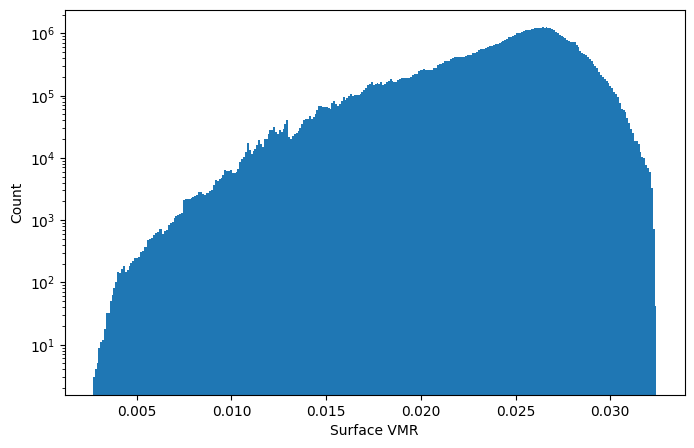

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(vmr.ravel(), bins=300)

plt.xlabel("Surface VMR")
plt.ylabel("Count")

plt.yscale("log")

plt.show()

In [8]:
import numpy as np

for step in [5e-6,1e-5,2e-5,5e-5,1e-4,2e-4,5e-4,1e-3]:

    q = np.round(vmr/step).astype(np.int32)

    print(
        f"{step:8g} -> {len(np.unique(q))}"
    )

   5e-06 -> 5834
   1e-05 -> 2935
   2e-05 -> 1478
   5e-05 -> 596
  0.0001 -> 298
  0.0002 -> 150
  0.0005 -> 61
   0.001 -> 30


In [9]:
for step in [5e-6,1e-5,2e-5,5e-5,1e-4,2e-4]:

    profiles = np.column_stack([
        idx.ravel(),
        np.round(ps/Pstep).astype(np.int32).ravel(),
        np.round(ts/Tstep).astype(np.int32).ravel(),
        np.round(vmr/step).astype(np.int32).ravel(),
    ])

    print(step, len(np.unique(profiles, axis=0)))

5e-06 4551497
1e-05 2881979
2e-05 1976018
5e-05 1356847
0.0001 1063836
0.0002 819488


Sampling baseline atmospheres...
  collected 1/100
  collected 2/100
  collected 3/100
  collected 4/100
  collected 5/100
  collected 6/100
  collected 7/100
  collected 8/100
  collected 9/100
  collected 10/100
  collected 11/100
  collected 12/100
  collected 13/100
  collected 14/100
  collected 15/100
  collected 16/100
  collected 17/100
  collected 18/100
  collected 19/100
  collected 20/100
  collected 21/100
  collected 22/100
  collected 23/100
  collected 24/100
  collected 25/100
  collected 26/100
  collected 27/100
  collected 28/100
  collected 29/100
  collected 30/100
  collected 31/100
  collected 32/100
  collected 33/100
  collected 34/100
  collected 35/100
  collected 36/100
  collected 37/100
  collected 38/100
  collected 39/100
  collected 40/100
  collected 41/100
  collected 42/100
  collected 43/100
  collected 44/100
  collected 45/100
  collected 46/100
  collected 47/100
  collected 48/100
  collected 49/100
  collected 50/100
  collected 51/100
  colle

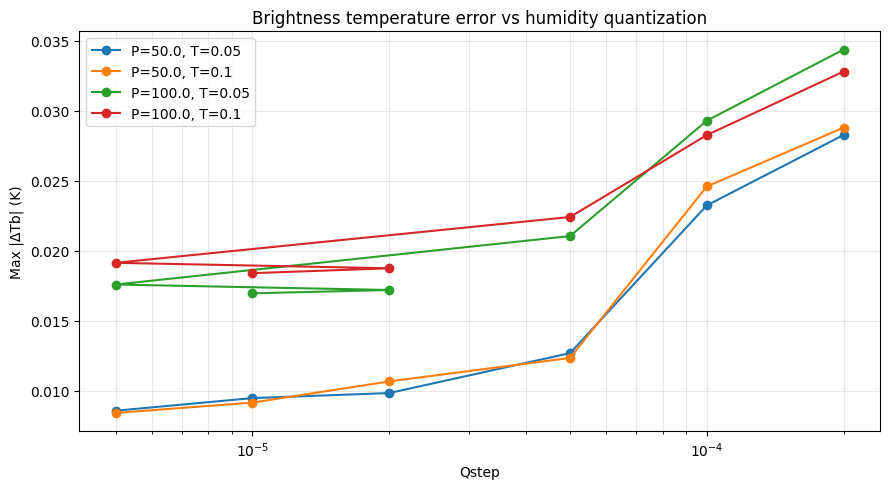


Done.


In [10]:
import os
import csv
import time
import tempfile
import subprocess
from itertools import product

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"
DERIVED = os.path.join(BASE, "Derived_things")
SITE_DIR = os.path.join(BASE, "ERA5_DATABASE", "site_87603_771167")
AM_EXE = os.path.join(BASE, "am.exe")

OUTDIR = os.path.join(BASE, "quantization_benchmark")
os.makedirs(OUTDIR, exist_ok=True)

# Surface fields
ps  = np.load(os.path.join(DERIVED, "ps.npy"))               # (T,H,W)
ts  = np.load(os.path.join(DERIVED, "ts.npy"))               # (T,H,W)
vmr_surface = np.load(os.path.join(DERIVED, "vmr_surface.npy"))  # (T,H,W)
idx = np.load(os.path.join(DERIVED, "insert_idx.npy"))       # (T,H,W)

# Upper-air fields
temp = np.load(os.path.join(DERIVED, "temp.npy"))            # (T,13)
vmr_upper = np.load(os.path.join(DERIVED, "vmr_q.npy"))      # (T,13)

meta = np.load(os.path.join(SITE_DIR, "metadata_pressure.npz"))
levels_pa = np.asarray(meta["pressure_levels"], dtype=np.float32) * 100.0  # Pa

T, H, W = ps.shape
n_levels = len(levels_pa)

# ============================================================
# SETTINGS
# ============================================================

RNG_SEED = 12345
N_SAMPLES = 100
MAX_RETRIES = 3

# Small grid search; expand if you want, but this is already a lot of AM runs.
P_STEPS = [50.0, 100.0]
T_STEPS = [0.05, 0.1]
Q_STEPS = [5e-6, 1e-5, 2e-5, 5e-5, 1e-4, 2e-4]

# ============================================================
# HELPERS
# ============================================================

rng = np.random.default_rng(RNG_SEED)

def parse_am_output(stdout: str):
    rows = []
    for line in stdout.splitlines():
        line = line.strip()
        if not line:
            continue
        if line[0] in "#!?":
            continue
        cols = line.split()
        if len(cols) < 3:
            continue
        try:
            rows.append([float(cols[0]), float(cols[1]), float(cols[2])])
        except ValueError:
            pass

    if not rows:
        return None

    arr = np.asarray(rows, dtype=np.float32)
    return arr[:, 0], arr[:, 1], arr[:, 2]   # freq, tau, Tb


def build_profile(t, y, x, Pstep=None, Tstep=None, Qstep=None):
    """
    Build the full pressure / temperature / VMR profile for one pixel-time.
    If Pstep/Tstep/Qstep are provided, quantize the full profile.
    """
    ins = int(idx[t, y, x])

    p = np.insert(levels_pa, ins, float(ps[t, y, x])).astype(np.float32)
    tt = np.insert(temp[t], ins, float(ts[t, y, x])).astype(np.float32)
    q = np.insert(vmr_upper[t], ins, float(vmr_surface[t, y, x])).astype(np.float32)

    if Pstep is not None:
        p = np.round(p / Pstep) * Pstep
    if Tstep is not None:
        tt = np.round(tt / Tstep) * Tstep
    if Qstep is not None:
        q = np.round(q / Qstep) * Qstep

    return p, tt, q, ins


def profile_to_amc_text(p, tt, q, ins):
    """
    Convert one profile to AM input text.
    """
    # AM expects only the atmosphere above the surface, top -> bottom
    P_use = p[ins:][::-1]
    T_use = tt[ins:][::-1]
    Q_use = q[ins:][::-1]

    lines = [
        "f 2 GHz 14 GHz 0.01 GHz",
        "output f GHz tx Tb K",
        "T0 2.7 K",
        "za 0 deg",
        ""
    ]

    for P, T_, Q in zip(P_use, T_use, Q_use):
        lines.append("layer")
        lines.append(f"Pbase {P:.1f} Pa")
        lines.append(f"Tbase {T_:.6f} K")
        lines.append("column dry_air hydrostatic")
        lines.append(f"column h2o vmr {Q:.10e}")
        lines.append("")

    return "\n".join(lines)


def run_am_from_text(amc_text, work_dir, amc_name="temp.amc"):
    """
    Write one temp AMC file, run AM, and parse the spectrum.
    Retries a few times.
    """
    amc_path = os.path.join(work_dir, amc_name)

    for _ in range(MAX_RETRIES):
        with open(amc_path, "w", encoding="utf-8", newline="\n") as f:
            f.write(amc_text)

        result = subprocess.run(
            [AM_EXE, amc_path],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            encoding="utf-8",
            errors="ignore",
        )

        parsed = parse_am_output(result.stdout)
        if parsed is not None:
            return parsed

    return None


def run_one_case(t, y, x, Pstep=None, Tstep=None, Qstep=None, work_dir=None):
    p, tt, q, ins = build_profile(t, y, x, Pstep=Pstep, Tstep=Tstep, Qstep=Qstep)
    amc_text = profile_to_amc_text(p, tt, q, ins)
    return run_am_from_text(amc_text, work_dir=work_dir)


# ============================================================
# SAMPLE 100 VALID ATMOSPHERES
# ============================================================

print("Sampling baseline atmospheres...")
valid_samples = []
ref_freq = None
ref_tau = []
ref_tb = []

with tempfile.TemporaryDirectory(dir=OUTDIR, prefix="am_benchmark_") as work_dir:
    attempts = 0
    target = N_SAMPLES

    while len(valid_samples) < target and attempts < target * 20:
        attempts += 1
        flat = rng.integers(0, T * H * W)
        t, y, x = np.unravel_index(flat, (T, H, W))

        if (t, y, x) in valid_samples:
            continue

        out = run_one_case(t, y, x, work_dir=work_dir)
        if out is None:
            continue

        freq, tau, tb = out

        if ref_freq is None:
            ref_freq = freq
        else:
            # If AM ever changes the grid slightly, align to baseline.
            if not np.array_equal(freq, ref_freq):
                tau = np.interp(ref_freq, freq, tau).astype(np.float32)
                tb = np.interp(ref_freq, freq, tb).astype(np.float32)

        valid_samples.append((t, y, x))
        ref_tau.append(tau)
        ref_tb.append(tb)

        print(f"  collected {len(valid_samples)}/{target}")

    if len(valid_samples) < target:
        raise RuntimeError(f"Only collected {len(valid_samples)} valid samples.")

ref_tau = np.asarray(ref_tau, dtype=np.float32)  # (N_SAMPLES, n_freq)
ref_tb = np.asarray(ref_tb, dtype=np.float32)    # (N_SAMPLES, n_freq)

np.save(os.path.join(OUTDIR, "sample_indices.npy"), np.array(valid_samples, dtype=np.int32))
np.save(os.path.join(OUTDIR, "reference_frequency.npy"), ref_freq)
np.save(os.path.join(OUTDIR, "reference_tau.npy"), ref_tau)
np.save(os.path.join(OUTDIR, "reference_tb.npy"), ref_tb)

print("Baseline sampling done.")
print("Reference spectrum shape:", ref_tau.shape)

# ============================================================
# GRID SEARCH OVER QUANTIZATION STEPS
# ============================================================

print("\nRunning quantization benchmark...")

results = []

with tempfile.TemporaryDirectory(dir=OUTDIR, prefix="am_benchmark_") as work_dir:

    for Pstep, Tstep, Qstep in product(P_STEPS, T_STEPS, Q_STEPS):

        all_dtau = []
        all_dtb = []
        failed = 0

        print(f"\nTesting P={Pstep}, T={Tstep}, Q={Qstep}")

        for k, (t, y, x) in enumerate(valid_samples):

            out = run_one_case(
                t, y, x,
                Pstep=Pstep,
                Tstep=Tstep,
                Qstep=Qstep,
                work_dir=work_dir
            )

            if out is None:
                failed += 1
                continue

            freq, tau, tb = out

            if not np.array_equal(freq, ref_freq):
                tau = np.interp(ref_freq, freq, tau).astype(np.float32)
                tb = np.interp(ref_freq, freq, tb).astype(np.float32)

            err_tau = np.abs(tau - ref_tau[k])
            err_tb = np.abs(tb - ref_tb[k])

            all_dtau.append(err_tau)
            all_dtb.append(err_tb)

        if not all_dtau:
            print("  all runs failed for this combo")
            continue

        err_tau = np.concatenate(all_dtau)
        err_tb = np.concatenate(all_dtb)

        row = {
            "Pstep": Pstep,
            "Tstep": Tstep,
            "Qstep": Qstep,
            "failed_runs": failed,
            "max_dTau": float(err_tau.max()),
            "mean_dTau": float(err_tau.mean()),
            "p95_dTau": float(np.percentile(err_tau, 95)),
            "max_dTb": float(err_tb.max()),
            "mean_dTb": float(err_tb.mean()),
            "p95_dTb": float(np.percentile(err_tb, 95)),
        }
        results.append(row)

        print(
            f"  failed={failed}  "
            f"maxΔTb={row['max_dTb']:.4f} K  "
            f"meanΔTb={row['mean_dTb']:.4f} K  "
            f"maxΔτ={row['max_dTau']:.6f}"
        )

# ============================================================
# SAVE RESULTS
# ============================================================

results = sorted(results, key=lambda r: (r["max_dTb"], r["max_dTau"]))

csv_path = os.path.join(OUTDIR, "quantization_benchmark_results.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(results[0].keys()))
    writer.writeheader()
    writer.writerows(results)

print("\nSaved:", csv_path)

# ============================================================
# PRINT SUMMARY TABLE
# ============================================================

print("\nTop 10 combos by smallest max ΔTb:")
for r in results[:10]:
    print(
        f"P={r['Pstep']:<6} T={r['Tstep']:<6} Q={r['Qstep']:<8g}  "
        f"maxΔTb={r['max_dTb']:.4f}  meanΔTb={r['mean_dTb']:.4f}  "
        f"maxΔτ={r['max_dTau']:.6f}"
    )

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))
for Pstep in P_STEPS:
    for Tstep in T_STEPS:
        xs = []
        ys = []
        for r in results:
            if r["Pstep"] == Pstep and r["Tstep"] == Tstep:
                xs.append(r["Qstep"])
                ys.append(r["max_dTb"])
        if xs:
            plt.plot(xs, ys, marker="o", label=f"P={Pstep}, T={Tstep}")

plt.xscale("log")
plt.xlabel("Qstep")
plt.ylabel("Max |ΔTb| (K)")
plt.title("Brightness temperature error vs humidity quantization")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nDone.")

Sampling baseline atmospheres...
  collected 1/100
  collected 2/100
  collected 3/100
  collected 4/100
  collected 5/100
  collected 6/100
  collected 7/100
  collected 8/100
  collected 9/100
  collected 10/100
  collected 11/100
  collected 12/100
  collected 13/100
  collected 14/100
  collected 15/100
  collected 16/100
  collected 17/100
  collected 18/100
  collected 19/100
  collected 20/100
  collected 21/100
  collected 22/100
  collected 23/100
  collected 24/100
  collected 25/100
  collected 26/100
  collected 27/100
  collected 28/100
  collected 29/100
  collected 30/100
  collected 31/100
  collected 32/100
  collected 33/100
  collected 34/100
  collected 35/100
  collected 36/100
  collected 37/100
  collected 38/100
  collected 39/100
  collected 40/100
  collected 41/100
  collected 42/100
  collected 43/100
  collected 44/100
  collected 45/100
  collected 46/100
  collected 47/100
  collected 48/100
  collected 49/100
  collected 50/100
  collected 51/100
  colle

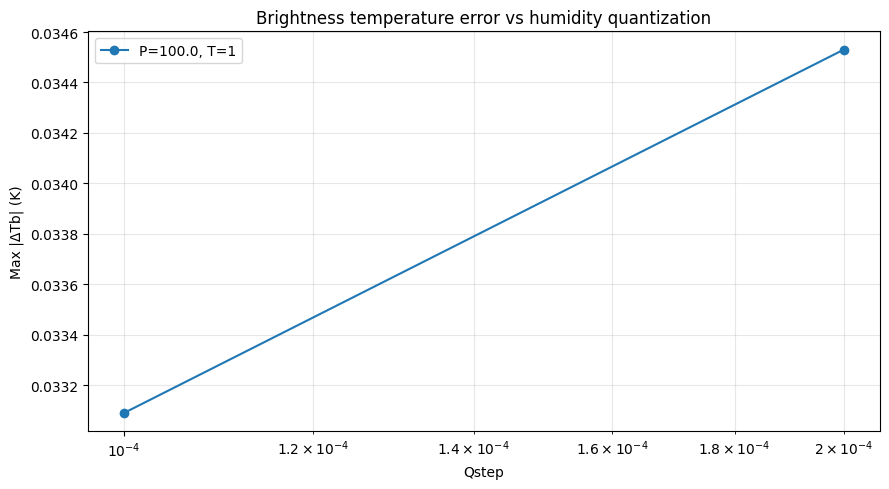


Done.


In [13]:
import os
import csv
import time
import tempfile
import subprocess
from itertools import product

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUTS
# ============================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"
DERIVED = os.path.join(BASE, "Derived_things")
SITE_DIR = os.path.join(BASE, "ERA5_DATABASE", "site_87603_771167")
AM_EXE = os.path.join(BASE, "am.exe")

OUTDIR = os.path.join(BASE, "quantization_benchmark")
os.makedirs(OUTDIR, exist_ok=True)

# Surface fields
ps  = np.load(os.path.join(DERIVED, "ps.npy"))               # (T,H,W)
ts  = np.load(os.path.join(DERIVED, "ts.npy"))               # (T,H,W)
vmr_surface = np.load(os.path.join(DERIVED, "vmr_surface.npy"))  # (T,H,W)
idx = np.load(os.path.join(DERIVED, "insert_idx.npy"))       # (T,H,W)

# Upper-air fields
temp = np.load(os.path.join(DERIVED, "temp.npy"))            # (T,13)
vmr_upper = np.load(os.path.join(DERIVED, "vmr_q.npy"))      # (T,13)

meta = np.load(os.path.join(SITE_DIR, "metadata_pressure.npz"))
levels_pa = np.asarray(meta["pressure_levels"], dtype=np.float32) * 100.0  # Pa

T, H, W = ps.shape
n_levels = len(levels_pa)

# ============================================================
# SETTINGS
# ============================================================

RNG_SEED = np.random.randint(0,100)
N_SAMPLES = 100
MAX_RETRIES = 3

# Small grid search; expand if you want, but this is already a lot of AM runs.
P_STEPS = [ 100.0]
T_STEPS = [1]
Q_STEPS = [ 1e-4, 2e-4]

# ============================================================
# HELPERS
# ============================================================

rng = np.random.default_rng(RNG_SEED)

def parse_am_output(stdout: str):
    rows = []
    for line in stdout.splitlines():
        line = line.strip()
        if not line:
            continue
        if line[0] in "#!?":
            continue
        cols = line.split()
        if len(cols) < 3:
            continue
        try:
            rows.append([float(cols[0]), float(cols[1]), float(cols[2])])
        except ValueError:
            pass

    if not rows:
        return None

    arr = np.asarray(rows, dtype=np.float32)
    return arr[:, 0], arr[:, 1], arr[:, 2]   # freq, tau, Tb


def build_profile(t, y, x, Pstep=None, Tstep=None, Qstep=None):
    """
    Build the full pressure / temperature / VMR profile for one pixel-time.
    If Pstep/Tstep/Qstep are provided, quantize the full profile.
    """
    ins = int(idx[t, y, x])

    p = np.insert(levels_pa, ins, float(ps[t, y, x])).astype(np.float32)
    tt = np.insert(temp[t], ins, float(ts[t, y, x])).astype(np.float32)
    q = np.insert(vmr_upper[t], ins, float(vmr_surface[t, y, x])).astype(np.float32)

    if Pstep is not None:
        p = np.round(p / Pstep) * Pstep
    if Tstep is not None:
        tt = np.round(tt / Tstep) * Tstep
    if Qstep is not None:
        q = np.round(q / Qstep) * Qstep

    return p, tt, q, ins


def profile_to_amc_text(p, tt, q, ins):
    """
    Convert one profile to AM input text.
    """
    # AM expects only the atmosphere above the surface, top -> bottom
    P_use = p[ins:][::-1]
    T_use = tt[ins:][::-1]
    Q_use = q[ins:][::-1]

    lines = [
        "f 2 GHz 14 GHz 0.01 GHz",
        "output f GHz tx Tb K",
        "T0 2.7 K",
        "za 0 deg",
        ""
    ]

    for P, T_, Q in zip(P_use, T_use, Q_use):
        lines.append("layer")
        lines.append(f"Pbase {P:.1f} Pa")
        lines.append(f"Tbase {T_:.6f} K")
        lines.append("column dry_air hydrostatic")
        lines.append(f"column h2o vmr {Q:.10e}")
        lines.append("")

    return "\n".join(lines)


def run_am_from_text(amc_text, work_dir, amc_name="temp.amc"):
    """
    Write one temp AMC file, run AM, and parse the spectrum.
    Retries a few times.
    """
    amc_path = os.path.join(work_dir, amc_name)

    for _ in range(MAX_RETRIES):
        with open(amc_path, "w", encoding="utf-8", newline="\n") as f:
            f.write(amc_text)

        result = subprocess.run(
            [AM_EXE, amc_path],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            encoding="utf-8",
            errors="ignore",
        )

        parsed = parse_am_output(result.stdout)
        if parsed is not None:
            return parsed

    return None


def run_one_case(t, y, x, Pstep=None, Tstep=None, Qstep=None, work_dir=None):
    p, tt, q, ins = build_profile(t, y, x, Pstep=Pstep, Tstep=Tstep, Qstep=Qstep)
    amc_text = profile_to_amc_text(p, tt, q, ins)
    return run_am_from_text(amc_text, work_dir=work_dir)


# ============================================================
# SAMPLE 100 VALID ATMOSPHERES
# ============================================================

print("Sampling baseline atmospheres...")
valid_samples = []
ref_freq = None
ref_tau = []
ref_tb = []

with tempfile.TemporaryDirectory(dir=OUTDIR, prefix="am_benchmark_") as work_dir:
    attempts = 0
    target = N_SAMPLES

    while len(valid_samples) < target and attempts < target * 20:
        attempts += 1
        flat = rng.integers(0, T * H * W)
        t, y, x = np.unravel_index(flat, (T, H, W))

        if (t, y, x) in valid_samples:
            continue

        out = run_one_case(t, y, x, work_dir=work_dir)
        if out is None:
            continue

        freq, tau, tb = out

        if ref_freq is None:
            ref_freq = freq
        else:
            # If AM ever changes the grid slightly, align to baseline.
            if not np.array_equal(freq, ref_freq):
                tau = np.interp(ref_freq, freq, tau).astype(np.float32)
                tb = np.interp(ref_freq, freq, tb).astype(np.float32)

        valid_samples.append((t, y, x))
        ref_tau.append(tau)
        ref_tb.append(tb)

        print(f"  collected {len(valid_samples)}/{target}")

    if len(valid_samples) < target:
        raise RuntimeError(f"Only collected {len(valid_samples)} valid samples.")

ref_tau = np.asarray(ref_tau, dtype=np.float32)  # (N_SAMPLES, n_freq)
ref_tb = np.asarray(ref_tb, dtype=np.float32)    # (N_SAMPLES, n_freq)

np.save(os.path.join(OUTDIR, "sample_indices.npy"), np.array(valid_samples, dtype=np.int32))
np.save(os.path.join(OUTDIR, "reference_frequency.npy"), ref_freq)
np.save(os.path.join(OUTDIR, "reference_tau.npy"), ref_tau)
np.save(os.path.join(OUTDIR, "reference_tb.npy"), ref_tb)

print("Baseline sampling done.")
print("Reference spectrum shape:", ref_tau.shape)

# ============================================================
# GRID SEARCH OVER QUANTIZATION STEPS
# ============================================================

print("\nRunning quantization benchmark...")

results = []

with tempfile.TemporaryDirectory(dir=OUTDIR, prefix="am_benchmark_") as work_dir:

    for Pstep, Tstep, Qstep in product(P_STEPS, T_STEPS, Q_STEPS):

        all_dtau = []
        all_dtb = []
        failed = 0

        print(f"\nTesting P={Pstep}, T={Tstep}, Q={Qstep}")

        for k, (t, y, x) in enumerate(valid_samples):

            out = run_one_case(
                t, y, x,
                Pstep=Pstep,
                Tstep=Tstep,
                Qstep=Qstep,
                work_dir=work_dir
            )

            if out is None:
                failed += 1
                continue

            freq, tau, tb = out

            if not np.array_equal(freq, ref_freq):
                tau = np.interp(ref_freq, freq, tau).astype(np.float32)
                tb = np.interp(ref_freq, freq, tb).astype(np.float32)

            err_tau = np.abs(tau - ref_tau[k])
            err_tb = np.abs(tb - ref_tb[k])

            all_dtau.append(err_tau)
            all_dtb.append(err_tb)

        if not all_dtau:
            print("  all runs failed for this combo")
            continue

        err_tau = np.concatenate(all_dtau)
        err_tb = np.concatenate(all_dtb)

        row = {
            "Pstep": Pstep,
            "Tstep": Tstep,
            "Qstep": Qstep,
            "failed_runs": failed,
            "max_dTau": float(err_tau.max()),
            "mean_dTau": float(err_tau.mean()),
            "p95_dTau": float(np.percentile(err_tau, 95)),
            "max_dTb": float(err_tb.max()),
            "mean_dTb": float(err_tb.mean()),
            "p95_dTb": float(np.percentile(err_tb, 95)),
        }
        results.append(row)

        print(
            f"  failed={failed}  "
            f"maxΔTb={row['max_dTb']:.4f} K  "
            f"meanΔTb={row['mean_dTb']:.4f} K  "
            f"maxΔτ={row['max_dTau']:.6f}"
        )

# ============================================================
# SAVE RESULTS
# ============================================================

results = sorted(results, key=lambda r: (r["max_dTb"], r["max_dTau"]))

csv_path = os.path.join(OUTDIR, "quantization_benchmark_results.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(results[0].keys()))
    writer.writeheader()
    writer.writerows(results)

print("\nSaved:", csv_path)

# ============================================================
# PRINT SUMMARY TABLE
# ============================================================

print("\nTop 10 combos by smallest max ΔTb:")
for r in results[:10]:
    print(
        f"P={r['Pstep']:<6} T={r['Tstep']:<6} Q={r['Qstep']:<8g}  "
        f"maxΔTb={r['max_dTb']:.4f}  meanΔTb={r['mean_dTb']:.4f}  "
        f"maxΔτ={r['max_dTau']:.6f}"
    )

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))
for Pstep in P_STEPS:
    for Tstep in T_STEPS:
        xs = []
        ys = []
        for r in results:
            if r["Pstep"] == Pstep and r["Tstep"] == Tstep:
                xs.append(r["Qstep"])
                ys.append(r["max_dTb"])
        if xs:
            plt.plot(xs, ys, marker="o", label=f"P={Pstep}, T={Tstep}")

plt.xscale("log")
plt.xlabel("Qstep")
plt.ylabel("Max |ΔTb| (K)")
plt.title("Brightness temperature error vs humidity quantization")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nDone.")

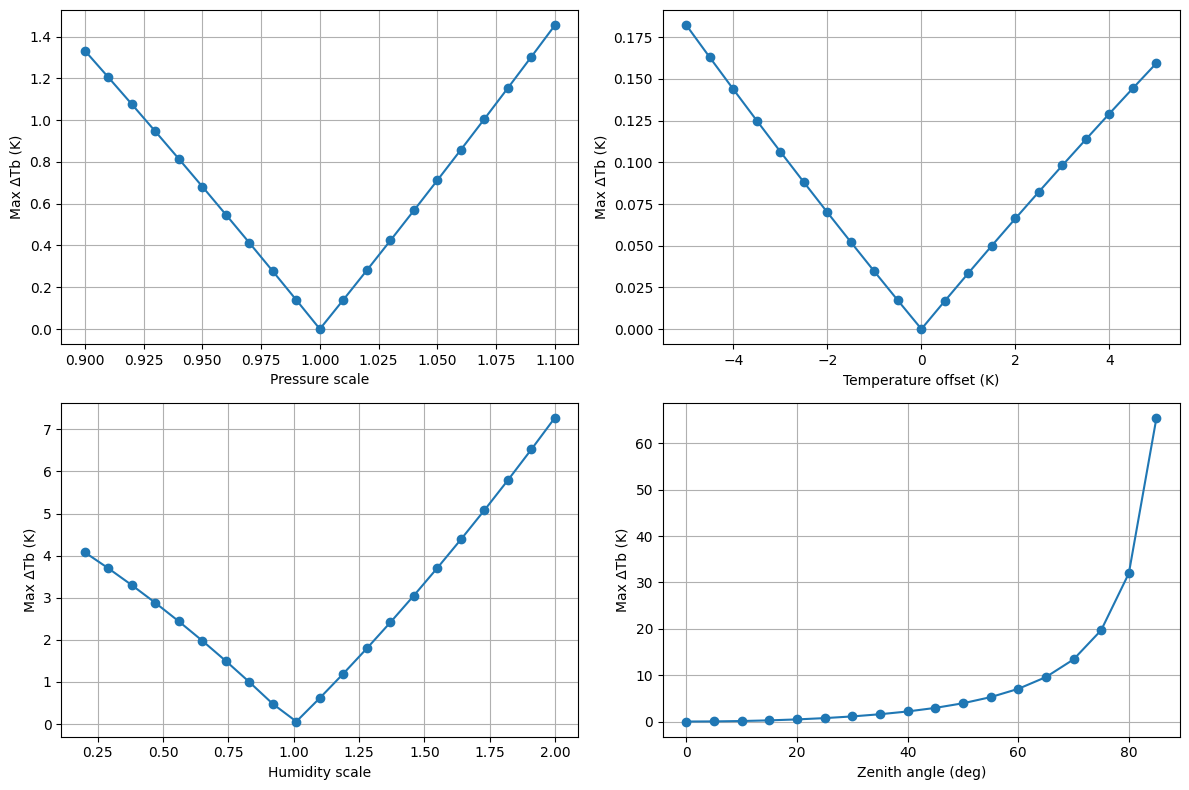

In [16]:
import os
import subprocess
import tempfile

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"
AM_EXE = os.path.join(BASE, "am.exe")

DERIVED = os.path.join(BASE, "Derived_things")
SITE = os.path.join(BASE, "ERA5_DATABASE", "site_87603_771167")

# ==========================================================
# LOAD DATA
# ==========================================================

ps = np.load(os.path.join(DERIVED, "ps.npy"))
ts = np.load(os.path.join(DERIVED, "ts.npy"))
vmr_surface = np.load(os.path.join(DERIVED, "vmr_surface.npy"))
insert_idx = np.load(os.path.join(DERIVED, "insert_idx.npy"))

temp = np.load(os.path.join(DERIVED, "temp.npy"))
vmr_upper = np.load(os.path.join(DERIVED, "vmr_q.npy"))

meta = np.load(os.path.join(SITE, "metadata_pressure.npz"))
levels = np.asarray(meta["pressure_levels"], dtype=np.float32) * 100.0

# ==========================================================
# CHOOSE ONE ATMOSPHERE
# ==========================================================

t = 100
i = 60
j = 60

ins = int(insert_idx[t, i, j])

P0 = np.insert(levels, ins, ps[t, i, j]).astype(np.float32)
T0 = np.insert(temp[t], ins, ts[t, i, j]).astype(np.float32)
Q0 = np.insert(vmr_upper[t], ins, vmr_surface[t, i, j]).astype(np.float32)

# ==========================================================
# AMC BUILDING
# ==========================================================

def make_amc(P, T, Q, ins, za):
    lines = [
        "f 2 GHz 14 GHz 0.01 GHz",
        "output f GHz tx Tb K",
        "T0 2.7 K",
        f"za {za:.2f} deg",
        "",
    ]

    P_use = P[ins:][::-1]
    T_use = T[ins:][::-1]
    Q_use = Q[ins:][::-1]

    for p, tt, q in zip(P_use, T_use, Q_use):
        lines.append("layer")
        lines.append(f"Pbase {p:.1f} Pa")
        lines.append(f"Tbase {tt:.6f} K")
        lines.append("column dry_air hydrostatic")
        lines.append(f"column h2o vmr {q:.10e}")
        lines.append("")

    return "\n".join(lines)

# ==========================================================
# RUN AM
# ==========================================================

def run_am(P, T, Q, za):
    with tempfile.TemporaryDirectory() as d:
        fname = os.path.join(d, "temp.amc")

        with open(fname, "w", encoding="utf-8", newline="\n") as f:
            f.write(make_amc(P, T, Q, ins, za))

        r = subprocess.run(
            [AM_EXE, fname],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            encoding="utf-8",
            errors="ignore",
        )

        rows = []
        for line in r.stdout.splitlines():
            line = line.strip()
            if not line:
                continue
            if line[0] in "#!?":
                continue

            s = line.split()
            if len(s) < 3:
                continue

            try:
                rows.append([float(s[0]), float(s[1]), float(s[2])])
            except ValueError:
                pass

        if len(rows) == 0:
            print("=" * 60)
            print("AM FAILED")
            print("ZA =", za)
            print("Return code:", r.returncode)
            print("STDERR:")
            print(r.stderr)
            print("STDOUT:")
            print(r.stdout)
            print("=" * 60)
            return None

        rows = np.asarray(rows, dtype=np.float32)
        return rows[:, 0], rows[:, 1], rows[:, 2]

# ==========================================================
# BASELINE
# ==========================================================

base_out = run_am(P0, T0, Q0, 0)
if base_out is None:
    raise RuntimeError("Baseline AM run failed at ZA=0.")

freq, tau_ref, tb_ref = base_out

# ==========================================================
# PRESSURE SENSITIVITY
# ==========================================================

pressure_scale = np.linspace(0.9, 1.1, 21)
pressure_error = []

for s in pressure_scale:
    out = run_am(P0 * s, T0, Q0, 0)
    if out is None:
        pressure_error.append(np.nan)
        continue
    _, _, tb = out
    pressure_error.append(np.max(np.abs(tb - tb_ref)))

pressure_error = np.asarray(pressure_error, dtype=np.float32)

# ==========================================================
# TEMPERATURE SENSITIVITY
# ==========================================================

temperature_offset = np.linspace(-5, 5, 21)
temperature_error = []

for dT in temperature_offset:
    out = run_am(P0, T0 + dT, Q0, 0)
    if out is None:
        temperature_error.append(np.nan)
        continue
    _, _, tb = out
    temperature_error.append(np.max(np.abs(tb - tb_ref)))

temperature_error = np.asarray(temperature_error, dtype=np.float32)

# ==========================================================
# HUMIDITY SENSITIVITY
# ==========================================================

humidity_scale = np.linspace(0.2, 2.0, 21)
humidity_error = []

for s in humidity_scale:
    out = run_am(P0, T0, Q0 * s, 0)
    if out is None:
        humidity_error.append(np.nan)
        continue
    _, _, tb = out
    humidity_error.append(np.max(np.abs(tb - tb_ref)))

humidity_error = np.asarray(humidity_error, dtype=np.float32)

# ==========================================================
# ZENITH ANGLE SENSITIVITY
# ==========================================================

angles = np.arange(0, 90, 5)   # avoid 90 deg
valid_angles = []
za_error = []

for za in angles:
    out = run_am(P0, T0, Q0, za)
    if out is None:
        continue
    _, _, tb = out
    valid_angles.append(za)
    za_error.append(np.max(np.abs(tb - tb_ref)))

valid_angles = np.asarray(valid_angles, dtype=np.float32)
za_error = np.asarray(za_error, dtype=np.float32)

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.plot(pressure_scale, pressure_error, "o-")
plt.xlabel("Pressure scale")
plt.ylabel("Max ΔTb (K)")
plt.grid(True)

plt.subplot(222)
plt.plot(temperature_offset, temperature_error, "o-")
plt.xlabel("Temperature offset (K)")
plt.ylabel("Max ΔTb (K)")
plt.grid(True)

plt.subplot(223)
plt.plot(humidity_scale, humidity_error, "o-")
plt.xlabel("Humidity scale")
plt.ylabel("Max ΔTb (K)")
plt.grid(True)

plt.subplot(224)
plt.plot(valid_angles, za_error, "o-")
plt.xlabel("Zenith angle (deg)")
plt.ylabel("Max ΔTb (K)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
import os
import time
import tempfile
import subprocess
import numpy as np

# ==========================================================
# SETTINGS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"
AM_EXE = os.path.join(BASE, "am.exe")
DERIVED = os.path.join(BASE, "Derived_things")
SITE = os.path.join(BASE, "ERA5_DATABASE", "site_87603_771167")

# New quantization
Pstep = 50.0
Tstep = 1.0
Qstep = 2e-4

# 3-hour cadence
TIME_STRIDE = 3

# Benchmark AM speed on a small sample
N_SAMPLE = 100

# New AM frequency grid
FMIN = 2.0
FMAX = 14.0
DF = 0.1   # 100 MHz = 0.1 GHz

# ==========================================================
# LOAD DATA
# ==========================================================

ps = np.load(os.path.join(DERIVED, "ps.npy"))
ts = np.load(os.path.join(DERIVED, "ts.npy"))
vmr_surface = np.load(os.path.join(DERIVED, "vmr_surface.npy"))
insert_idx = np.load(os.path.join(DERIVED, "insert_idx.npy"))

temp = np.load(os.path.join(DERIVED, "temp.npy"))
vmr_upper = np.load(os.path.join(DERIVED, "vmr_q.npy"))

meta = np.load(os.path.join(SITE, "metadata_pressure.npz"))
levels = np.asarray(meta["pressure_levels"], dtype=np.float32) * 100.0

T, H, W = ps.shape

# ==========================================================
# HELPERS
# ==========================================================

def build_amc_text(t, i, j):
    ins = int(insert_idx[t, i, j])

    P = np.insert(levels, ins, ps[t, i, j]).astype(np.float32)
    TT = np.insert(temp[t], ins, ts[t, i, j]).astype(np.float32)
    Q = np.insert(vmr_upper[t], ins, vmr_surface[t, i, j]).astype(np.float32)

    # quantize
    P = np.round(P / Pstep) * Pstep
    TT = np.round(TT / Tstep) * Tstep
    Q = np.round(Q / Qstep) * Qstep

    P_use = P[ins:][::-1]
    T_use = TT[ins:][::-1]
    Q_use = Q[ins:][::-1]

    lines = [
        f"f {FMIN} GHz {FMAX} GHz {DF} GHz",
        "output f GHz tx Tb K",
        "T0 2.7 K",
        "za 0 deg",
        "",
    ]

    for p, tt, q in zip(P_use, T_use, Q_use):
        lines.append("layer")
        lines.append(f"Pbase {p:.1f} Pa")
        lines.append(f"Tbase {tt:.6f} K")
        lines.append("column dry_air hydrostatic")
        lines.append(f"column h2o vmr {q:.10e}")
        lines.append("")

    return "\n".join(lines)

def run_am_from_text(amc_text):
    with tempfile.TemporaryDirectory() as d:
        amc_path = os.path.join(d, "temp.amc")
        with open(amc_path, "w", encoding="utf-8", newline="\n") as f:
            f.write(amc_text)

        r = subprocess.run(
            [AM_EXE, amc_path],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            encoding="utf-8",
            errors="ignore",
        )

        rows = []
        for line in r.stdout.splitlines():
            line = line.strip()
            if not line or line[0] in "#!?":
                continue
            cols = line.split()
            if len(cols) < 3:
                continue
            try:
                rows.append([float(cols[0]), float(cols[1]), float(cols[2])])
            except ValueError:
                pass

        if not rows:
            print("AM failed")
            print("stderr:")
            print(r.stderr)
            print("stdout:")
            print(r.stdout)
            return None

        rows = np.asarray(rows, dtype=np.float32)
        return rows[:, 0], rows[:, 1], rows[:, 2]

# ==========================================================
# 1) COUNT UNIQUE ATMOSPHERES WITH 3-HOUR CADENCE
# ==========================================================

t_idx = np.arange(0, T, TIME_STRIDE)

profiles = []

for t in t_idx:
    Pq = np.round(ps[t].ravel() / Pstep).astype(np.int32)
    Tq = np.round(ts[t].ravel() / Tstep).astype(np.int32)
    Qq = np.round(vmr_surface[t].ravel() / Qstep).astype(np.int32)
    Iq = insert_idx[t].ravel().astype(np.int32)

    # compact surface key; upper-air varies by timestep, so include timestep ID too
    # (this is just for counting surface-side reduction)
    keys = np.column_stack([Iq, Pq, Tq, Qq])
    profiles.append(keys)

all_keys = np.vstack(profiles)

unique_surface_keys = len(np.unique(all_keys, axis=0))

print("=" * 60)
print("3-hour timesteps used :", len(t_idx))
print("Unique surface keys    :", unique_surface_keys)
print("=" * 60)

# ==========================================================
# 2) BENCHMARK AM ON A SMALL SAMPLE
# ==========================================================

rng = np.random.default_rng(12345)

sample_pairs = []
seen = set()

attempts = 0
while len(sample_pairs) < N_SAMPLE and attempts < N_SAMPLE * 20:
    attempts += 1
    t = int(rng.choice(t_idx))
    i = int(rng.integers(0, H))
    j = int(rng.integers(0, W))
    key = (t, i, j)
    if key in seen:
        continue
    seen.add(key)
    sample_pairs.append(key)

print(f"\nCollected {len(sample_pairs)} sample atmospheres for timing.")

freq_ref = None
t0 = time.time()

ok = 0
for n, (t, i, j) in enumerate(sample_pairs, 1):
    amc_text = build_amc_text(t, i, j)
    out = run_am_from_text(amc_text)
    if out is None:
        continue
    freq, tau, tb = out
    if freq_ref is None:
        freq_ref = freq
    ok += 1
    if ok % 10 == 0 or ok == len(sample_pairs):
        print(f"  done {ok}/{len(sample_pairs)}")

elapsed = time.time() - t0

if ok == 0:
    raise RuntimeError("All benchmark AM runs failed.")

sec_per_case = elapsed / ok

# ==========================================================
# 3) ESTIMATE FULL-RUN TIME
# ==========================================================

estimated_hours = unique_surface_keys * sec_per_case / 3600.0

print("\n" + "=" * 60)
print("Benchmark results")
print("=" * 60)
print(f"Successful benchmark cases : {ok}/{len(sample_pairs)}")
print(f"Seconds per atmosphere     : {sec_per_case:.3f}")
print(f"Estimated total hours      : {estimated_hours:.2f}")
print(f"Estimated total days       : {estimated_hours/24:.2f}")
print("=" * 60)

# Optional: save the estimate
np.savez(
    os.path.join(BASE, "quantization_runtime_estimate.npz"),
    unique_surface_keys=unique_surface_keys,
    seconds_per_case=sec_per_case,
    estimated_hours=estimated_hours,
    freq_ref=freq_ref if freq_ref is not None else np.array([]),
)

3-hour timesteps used : 974
Unique surface keys    : 94968

Collected 100 sample atmospheres for timing.
  done 10/100
  done 20/100
  done 30/100
  done 40/100
  done 50/100
  done 60/100
  done 70/100
  done 80/100
  done 90/100
  done 100/100

Benchmark results
Successful benchmark cases : 100/100
Seconds per atmosphere     : 0.417
Estimated total hours      : 11.00
Estimated total days       : 0.46


In [24]:
import os
import re
import json
import glob
from pathlib import Path

import numpy as np
import cupy as cp
import rasterio
from rasterio.mask import mask
from rasterio.transform import rowcol
from shapely.geometry import box, mapping
from numpy.lib.format import open_memmap

# ============================================================
# CONFIG
# ============================================================

BASE = Path(r"C:\Users\Darkrai\Projects\iitk proj")
ERA5_DIR = BASE / "ERA5_DATABASE" / "site_87603_771167"
DEM_PATH = BASE / "DEMs" / "ponmudi" / "Ponmudi.tif"
OUTDIR = BASE / "Derived_things"
OUTDIR.mkdir(parents=True, exist_ok=True)

TIME_STRIDE = 3          # notebook uses ::3
CHUNK_T = 100            # timesteps per GPU chunk
g = 9.80665
epsilon = 0.622

# ============================================================
# LOAD METADATA
# ============================================================

meta = np.load(ERA5_DIR / "metadata_pressure.npz")

target_lat = float(meta["target_lat"])
target_lon = float(meta["target_lon"])
tile_lat = np.asarray(meta["tile_latitudes"], dtype=np.float32)
tile_lon = np.asarray(meta["tile_longitudes"], dtype=np.float32)
levels_hpa = np.asarray(meta["pressure_levels"], dtype=np.float32)
levels_pa = cp.asarray(levels_hpa * 100.0, dtype=cp.float32)

lat_idx = int(np.argmin(np.abs(tile_lat - target_lat)))
lon_idx = int(np.argmin(np.abs(tile_lon - target_lon)))

np.savez(
    OUTDIR / "site_info.npz",
    target_lat=target_lat,
    target_lon=target_lon,
    lat_idx=lat_idx,
    lon_idx=lon_idx,
    tile_latitudes=tile_lat,
    tile_longitudes=tile_lon,
    pressure_levels_hpa=levels_hpa,
)

np.save(OUTDIR / "levels_pa.npy", levels_hpa * 100.0)

# ============================================================
# LOAD / CROP DEM
# ============================================================

with rasterio.open(DEM_PATH) as dem_src:
    bbox = box(
        float(tile_lon.min()),
        float(tile_lat.min()),
        float(tile_lon.max()),
        float(tile_lat.max()),
    )

    cropped_dem, cropped_transform = mask(
        dem_src,
        [mapping(bbox)],
        crop=True,
    )

cropped_dem = cropped_dem[0].astype(np.float32)

# row/col in the cropped DEM
row, col = rowcol(cropped_transform, target_lon, target_lat)
row = int(row)
col = int(col)

small_box = cropped_dem[row - 80 : row + 80, col - 80 : col + 80].astype(np.float32)

if small_box.shape != (160, 160):
    raise RuntimeError(f"Expected small_box shape (160,160), got {small_box.shape}")

np.save(OUTDIR / "small_box.npy", small_box)

# ============================================================
# FIND YEARLY INPUT FILES
# ============================================================

pressure_files = sorted(glob.glob(str(ERA5_DIR / "pressure_*.npz")))
if not pressure_files:
    raise FileNotFoundError(f"No pressure_*.npz files found in {ERA5_DIR}")

year_re = re.compile(r"pressure_(\d{4})\.npz$")

year_entries = []
for pfile in pressure_files:
    m = year_re.search(os.path.basename(pfile))
    if not m:
        continue
    year = int(m.group(1))
    with np.load(pfile) as pld:
        n_time = pld["temperature"][::TIME_STRIDE].shape[0]
    year_entries.append((year, pfile, n_time))

if not year_entries:
    raise RuntimeError("No valid yearly pressure files found.")

year_entries.sort(key=lambda x: x[0])

years = np.array([y for y, _, _ in year_entries], dtype=np.int32)
year_lengths = np.array([n for _, _, n in year_entries], dtype=np.int32)
year_offsets = np.zeros_like(year_lengths)
if len(year_offsets) > 1:
    year_offsets[1:] = np.cumsum(year_lengths[:-1])

total_T = int(year_lengths.sum())

np.save(OUTDIR / "years.npy", years)
np.save(OUTDIR / "year_lengths.npy", year_lengths)
np.save(OUTDIR / "year_offsets.npy", year_offsets)

with open(OUTDIR / "derived_manifest.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "time_stride": TIME_STRIDE,
            "chunk_T": CHUNK_T,
            "total_timesteps": total_T,
            "years": years.tolist(),
            "year_lengths": year_lengths.tolist(),
            "year_offsets": year_offsets.tolist(),
            "pressure_files": [os.path.basename(p) for _, p, _ in year_entries],
        },
        f,
        indent=2,
    )

print("=" * 70)
print(f"Years              : {years[0]} .. {years[-1]}")
print(f"Number of years    : {len(years)}")
print(f"Total timesteps    : {total_T}")
print(f"small_box shape    : {small_box.shape}")
print("=" * 70)

# ============================================================
# CREATE OUTPUT MEMMAPS
# ============================================================

H, W = small_box.shape
NLEV = len(levels_hpa)

temp_mm = open_memmap(OUTDIR / "temp.npy", mode="w+", dtype=np.float32, shape=(total_T, NLEV))
vmr_q_mm = open_memmap(OUTDIR / "vmr_q.npy", mode="w+", dtype=np.float32, shape=(total_T, NLEV))

insert_idx_mm = open_memmap(OUTDIR / "insert_idx.npy", mode="w+", dtype=np.uint8, shape=(total_T, H, W))
ratio_mm = open_memmap(OUTDIR / "ratio.npy", mode="w+", dtype=np.float32, shape=(total_T, H, W))
ps_mm = open_memmap(OUTDIR / "ps.npy", mode="w+", dtype=np.float32, shape=(total_T, H, W))
ts_mm = open_memmap(OUTDIR / "ts.npy", mode="w+", dtype=np.float32, shape=(total_T, H, W))
qs_mm = open_memmap(OUTDIR / "qs.npy", mode="w+", dtype=np.float32, shape=(total_T, H, W))
vmr_surface_mm = open_memmap(OUTDIR / "vmr_surface.npy", mode="w+", dtype=np.float32, shape=(total_T, H, W))
pwv_mm = open_memmap(OUTDIR / "pwv.npy", mode="w+", dtype=np.float32, shape=(total_T, H, W))

# ============================================================
# PROCESS
# ============================================================

small_box_cp = cp.asarray(small_box, dtype=cp.float32)
small_box_flat = cp.asarray(small_box.ravel(), dtype=cp.float32)

k_arr = cp.arange(14, dtype=cp.int16).reshape(1, 1, 1, 14)

t_global = 0

for year, pfile, n_time in year_entries:
    print(f"\n=== YEAR {year} ===")
    with np.load(pfile) as pld:
        temp_src = cp.asarray(pld["temperature"][::TIME_STRIDE, :, lat_idx, lon_idx], dtype=cp.float32)
        q_src = cp.asarray(pld["specific_humidity"][::TIME_STRIDE, :, lat_idx, lon_idx], dtype=cp.float32)
        z_src = cp.asarray(pld["geopotential"][::TIME_STRIDE, :, lat_idx, lon_idx], dtype=cp.float32) / g

    T_year = int(temp_src.shape[0])
    if T_year != n_time:
        print(f"  warning: expected {n_time} steps, got {T_year}")

    # Save the pressure-level fields (these are tiny compared to the DEM-sized arrays)
    temp_mm[t_global : t_global + T_year] = cp.asnumpy(temp_src)
    vmr_q_mm[t_global : t_global + T_year] = cp.asnumpy(q_src / (epsilon + (1.0 - epsilon) * q_src))

    # Chunk over time to keep GPU memory bounded
    for start in range(0, T_year, CHUNK_T):
        end = min(start + CHUNK_T, T_year)
        t_len = end - start

        z = z_src[start:end]   # (t, 13)
        q = q_src[start:end]   # (t, 13)
        tprof = temp_src[start:end]  # (t, 13)

        t_idx3 = cp.arange(t_len, dtype=cp.int32).reshape(t_len, 1, 1)
        t_idx4 = cp.arange(t_len, dtype=cp.int32).reshape(t_len, 1, 1, 1)

        # -------------------------------------------------------
        # Surface humidity and insertion index
        # -------------------------------------------------------
        idx = ((z[:, :, None] < small_box_flat).sum(axis=1)).astype(cp.int16)  # (t,H,W)
        insert_idx_mm[t_global + start : t_global + end] = cp.asnumpy(idx.astype(cp.uint8))

        q0 = q[t_idx3, idx - 1]
        q1 = q[t_idx3, idx]
        qs = q0 + (0.0 + 1.0) * 0  # no-op to keep structure obvious
        # ratio needs the height interpolation below, so compute it now

        # -------------------------------------------------------
        # Pressure interpolation geometry
        # -------------------------------------------------------
        pk = cp.log(levels_pa[idx - 1])
        pk_1 = cp.log(levels_pa[idx])

        z0 = z[t_idx3, idx - 1]
        z1 = z[t_idx3, idx]

        ratio = (small_box_cp - z0) / (z1 - z0)
        ps = cp.exp(pk + ratio * (pk_1 - pk))

        # -------------------------------------------------------
        # Temperature interpolation
        # -------------------------------------------------------
        t0 = tprof[t_idx3, idx - 1]
        t1 = tprof[t_idx3, idx]
        ts = t0 + ratio * (t1 - t0)

        # -------------------------------------------------------
        # Surface humidity interpolation
        # -------------------------------------------------------
        qs = q0 + ratio * (q1 - q0)

        # -------------------------------------------------------
        # Save derived fields
        # -------------------------------------------------------
        g0 = t_global + start
        g1 = t_global + end

        ratio_mm[g0:g1] = cp.asnumpy(ratio.astype(cp.float32))
        ps_mm[g0:g1] = cp.asnumpy(ps.astype(cp.float32))
        ts_mm[g0:g1] = cp.asnumpy(ts.astype(cp.float32))
        qs_mm[g0:g1] = cp.asnumpy(qs.astype(cp.float32))
        vmr_surface_mm[g0:g1] = cp.asnumpy(qs / (epsilon + (1.0 - epsilon) * qs))

        # -------------------------------------------------------
        # PWV integral
        # -------------------------------------------------------
        shift = (k_arr > idx[..., None]).astype(cp.int16)
        src = cp.clip(k_arr - shift, 0, 12)

        out = levels_pa[src]
        q_full = q[t_idx4, src]

        cp.put_along_axis(out, idx[..., None], ps[..., None], axis=3)
        cp.put_along_axis(q_full, idx[..., None], qs[..., None], axis=3)

        dp = cp.abs(out[..., 1:] - out[..., :-1])
        avg_q = 0.5 * (q_full[..., 1:] + q_full[..., :-1])

        k13 = cp.arange(13, dtype=cp.int16).reshape(1, 1, 1, 13)
        mask = k13 >= idx[..., None]

        integral = cp.sum(cp.where(mask, avg_q * dp, 0.0), axis=-1)
        pwv_mm[g0:g1] = cp.asnumpy(integral / g)

        cp._default_memory_pool.free_all_blocks()

        print(f"  {year}: done {g1 - t_global}/{T_year}", end="\r")

    t_global += T_year
    print(f"\n  finished {year}")

# ============================================================
# FLUSH / SAVE
# ============================================================

temp_mm.flush()
vmr_q_mm.flush()
insert_idx_mm.flush()
ratio_mm.flush()
ps_mm.flush()
ts_mm.flush()
qs_mm.flush()
vmr_surface_mm.flush()
pwv_mm.flush()

print("\nSaved to:", OUTDIR)
print("Files written:")
print("  temp.npy")
print("  vmr_q.npy")
print("  insert_idx.npy")
print("  ratio.npy")
print("  ps.npy")
print("  ts.npy")
print("  qs.npy")
print("  vmr_surface.npy")
print("  pwv.npy")
print("  site_info.npz")
print("  years.npy / year_lengths.npy / year_offsets.npy")

Years              : 2000 .. 2025
Number of years    : 26
Total timesteps    : 75976
small_box shape    : (160, 160)

=== YEAR 2000 ===


ValueError: could not broadcast input array from shape (100,25600) into shape (100,160,160)

In [1]:
import numpy as np
x=np.load(r'C:\Users\Darkrai\Projects\iitk proj\testing_ERA5_Data\site\surface_2025.npz')['total_precipitation']

Nearest ERA5 Grid Point
Target latitude : 26.496700
Target longitude: 80.241300

Grid latitude   : 26.500000
Grid longitude  : 80.250000

Grid indices    : (2, 9)

Maximum precipitation: 10.642529 mm


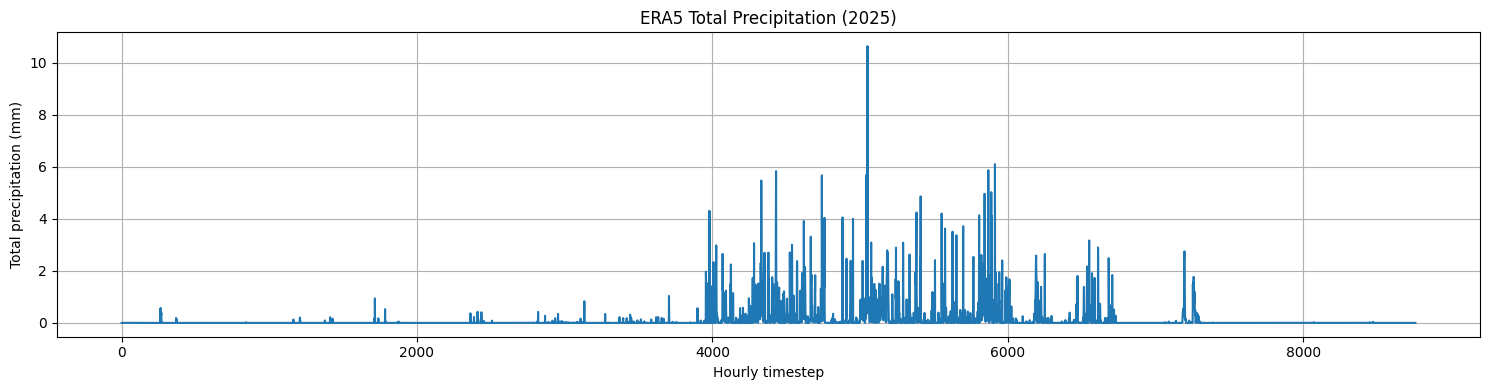

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

DATA_DIR = r"C:\Users\Darkrai\Projects\iitk proj\testing_ERA5_Data\site"

YEAR = 2025

TARGET_LAT = 26.4967
TARGET_LON = 80.2413


# ==========================================================
# LOAD DATA
# ==========================================================

ds = np.load(os.path.join(DATA_DIR, f"surface_{YEAR}.npz"))

lat = ds["latitude"]
lon = ds["longitude"]

tp = ds["total_precipitation"]      # (time, lat, lon)

time = ds["valid_time"]

# ==========================================================
# FIND NEAREST GRID POINT
# ==========================================================

TARGET_LON = TARGET_LON % 360

lat_idx = np.argmin(np.abs(lat - TARGET_LAT))
lon_idx = np.argmin(np.abs(lon - TARGET_LON))

print("="*60)
print("Nearest ERA5 Grid Point")
print("="*60)

print(f"Target latitude : {TARGET_LAT:.6f}")
print(f"Target longitude: {TARGET_LON:.6f}")

print()

print(f"Grid latitude   : {lat[lat_idx]:.6f}")
print(f"Grid longitude  : {lon[lon_idx]:.6f}")

print()

print(f"Grid indices    : ({lat_idx}, {lon_idx})")

# ==========================================================
# EXTRACT PRECIPITATION
# ==========================================================

tp_series = tp[:, lat_idx, lon_idx] * 1000.0   # convert m -> mm

print()
print("Maximum precipitation:", tp_series.max(), "mm")

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(15,4))

plt.plot(tp_series)

plt.grid(True)

plt.xlabel("Hourly timestep")

plt.ylabel("Total precipitation (mm)")

plt.title(f"ERA5 Total Precipitation ({YEAR})")

plt.tight_layout()

plt.show()

In [6]:
minimum_day_idx=np.argmin(tp_series)
maximum_day_idx=np.argmax(tp_series)

In [7]:
pressure_ds=np.load(r'C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_264967_802413\pressure_2025.npz')


Using tile pixel: 2 9


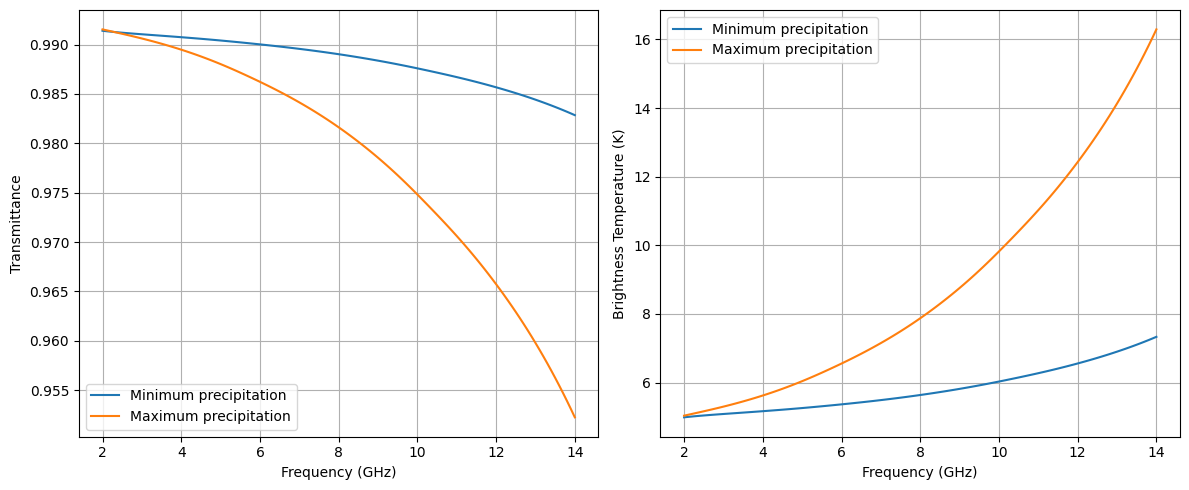

In [8]:
import os
import tempfile
import subprocess
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

AM_EXE = os.path.join(BASE, "am.exe")

g = 9.80665
epsilon = 0.622

# ==========================================================
# LOAD METADATA
# ==========================================================

meta = np.load(
    r"C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_264967_802413\metadata_pressure.npz"
)

levels = meta["pressure_levels"] * 100.0

# ==========================================================
# LOAD ARRAYS
# ==========================================================

surface = np.load(
    r"C:\Users\Darkrai\Projects\iitk proj\testing_ERA5_Data\site\surface_2025.npz"
)

pressure = np.load(
    r"C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_264967_802413\pressure_2025.npz"
)

# ----------------------------------------------------------
# Find nearest grid point inside downloaded tile
# ----------------------------------------------------------

lat = surface["latitude"]
lon = surface["longitude"]

lat_idx = np.argmin(np.abs(lat - TARGET_LAT))
lon_idx = np.argmin(np.abs(lon - (TARGET_LON % 360)))

print("Using tile pixel:", lat_idx, lon_idx)

# ==========================================================
# BUILD AM PROFILE
# ==========================================================

def build_profile(t):

    sp = surface["surface_pressure"][t, lat_idx, lon_idx]
    ts = surface["temperature_2m"][t, lat_idx, lon_idx]

    T = pressure["temperature"][t, :, lat_idx, lon_idx]

    q = pressure["specific_humidity"][t, :, lat_idx, lon_idx]

    z = pressure["geopotential"][t, :, lat_idx, lon_idx] / g

    vmr = q / (epsilon + (1 - epsilon) * q)

    insert = np.sum(z < 0.0)

    insert = np.clip(insert, 1, len(levels)-1)

    pk = np.log(levels[insert-1])
    pk1 = np.log(levels[insert])

    z0 = z[insert-1]
    z1 = z[insert]

    ratio = (0.0 - z0)/(z1-z0)

    ps = np.exp(pk + ratio*(pk1-pk))

    vmr_surface = (
        vmr[insert-1]
        + ratio*(vmr[insert]-vmr[insert-1])
    )

    ts = (
        T[insert-1]
        + ratio*(T[insert]-T[insert-1])
    )

    P = np.insert(levels, insert, ps)
    TT = np.insert(T, insert, ts)
    VV = np.insert(vmr, insert, vmr_surface)

    return insert, P, TT, VV

# ==========================================================
# WRITE AMC
# ==========================================================

def make_amc(P,T,V,insert):

    lines=[]

    lines.append("f 2 GHz 14 GHz 0.1 GHz")
    lines.append("output f GHz tx Tb K")
    lines.append("T0 2.7 K")
    lines.append("za 0 deg")
    lines.append("")

    P=P[insert:][::-1]
    T=T[insert:][::-1]
    V=V[insert:][::-1]

    for p,t,q in zip(P,T,V):

        lines.append("layer")
        lines.append(f"Pbase {p:.1f} Pa")
        lines.append(f"Tbase {t:.3f} K")
        lines.append("column dry_air hydrostatic")
        lines.append(f"column h2o vmr {q:.8e}")
        lines.append("")

    return "\n".join(lines)

# ==========================================================
# RUN AM
# ==========================================================

def run_am(timestep):

    insert,P,T,V = build_profile(timestep)

    with tempfile.TemporaryDirectory() as d:

        fname=os.path.join(d,"temp.amc")

        with open(fname,"w") as f:
            f.write(make_amc(P,T,V,insert))

        r=subprocess.run(
            [AM_EXE,fname],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )

        freq=[]
        tau=[]
        tb=[]

        for line in r.stdout.splitlines():

            line=line.strip()

            if not line:
                continue

            if line[0] in "#!?":
                continue

            s=line.split()

            if len(s)<3:
                continue

            try:

                freq.append(float(s[0]))
                tau.append(float(s[1]))
                tb.append(float(s[2]))

            except:
                pass

        return (
            np.asarray(freq),
            np.asarray(tau),
            np.asarray(tb)
        )

# ==========================================================
# RUN BOTH CASES
# ==========================================================

freq1,tau1,tb1 = run_am(minimum_day_idx)
freq2,tau2,tb2 = run_am(maximum_day_idx)

# ==========================================================
# PLOTS
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(121)

plt.plot(freq1,tau1,label="Minimum precipitation")
plt.plot(freq2,tau2,label="Maximum precipitation")

plt.xlabel("Frequency (GHz)")
plt.ylabel("Transmittance")
plt.grid()
plt.legend()

plt.subplot(122)

plt.plot(freq1,tb1,label="Minimum precipitation")
plt.plot(freq2,tb2,label="Maximum precipitation")

plt.xlabel("Frequency (GHz)")
plt.ylabel("Brightness Temperature (K)")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
import os
import tempfile
import subprocess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"
AM_EXE = os.path.join(BASE, "am.exe")

# ==========================================================
# DATASET PATHS
# ==========================================================

PRESSURE_ZARR = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
SINGLE_ZARR   = "gs://gcp-public-data-arco-era5/co/single-level-reanalysis.zarr-v2"

# ==========================================================
# SETTINGS
# ==========================================================

LAT = 26.4967
LON = 80.2413
TIME_IDX = 800000          # one hour only, just for testing

# Wide band so cloud effects are easier to see
FREQ_MIN = 2.0
FREQ_MAX = 2.3
FREQ_STEP = 0.00001

g = 9.80665
epsilon = 0.622

# ==========================================================
# OPEN DATASETS
# ==========================================================

pressure = xr.open_zarr(
    PRESSURE_ZARR,
    chunks=None,
    storage_options={"token": "anon"},
    decode_timedelta=True
)

single = xr.open_zarr(
    SINGLE_ZARR,
    chunks=None,
    storage_options={"token": "anon"},
    decode_timedelta=True
)

pressure_t = pressure.isel(time=TIME_IDX)
single_t = single.isel(time=TIME_IDX)

print("Opened datasets.")
print("Pressure vars:", list(pressure.data_vars)[:5], "...")
print("Single vars   :", list(single.data_vars))
print()

# ==========================================================
# EXTRACT AND SANITIZE ARRAYS
# ==========================================================

print("Downloading single-level data arrays (this may take a few seconds)...")
sp_vals   = single_t["sp"].values
tclw_vals = np.nan_to_num(single_t["tclw"].values, nan=0.0)
tciw_vals = np.nan_to_num(single_t["tciw"].values, nan=0.0)
tcrw_vals = np.nan_to_num(single_t["tcrw"].values, nan=0.0)
tcsw_vals = np.nan_to_num(single_t["tcsw"].values, nan=0.0)
tcwv_vals = np.nan_to_num(single_t["tcwv"].values, nan=0.0)

# ==========================================================
# FIND CLOUDIEST / DRIEST POINT AT THIS HOUR
# ==========================================================

cloud_metric = tclw_vals + tciw_vals + tcrw_vals + tcsw_vals

cloudiest_idx = int(np.argmax(cloud_metric))
driest_idx = int(np.argmin(cloud_metric))

def summarize_point(idx, label):
    lat_pt = float(single_t.latitude.values[idx])
    lon_pt = float(single_t.longitude.values[idx])
    sp   = float(sp_vals[idx])
    tclw = float(tclw_vals[idx])
    tciw = float(tciw_vals[idx])
    tcrw = float(tcrw_vals[idx])
    tcsw = float(tcsw_vals[idx])
    tcwv = float(tcwv_vals[idx])

    print(f"{label}:")
    print(f"  idx   = {idx}")
    print(f"  lat/lon = ({lat_pt:.4f}, {lon_pt:.4f})")
    print(f"  sp    = {sp:.2f} Pa")
    print(f"  tclw  = {tclw:.6f} kg/m^2")
    print(f"  tciw  = {tciw:.6f} kg/m^2")
    print(f"  tcrw  = {tcrw:.6f} kg/m^2")
    print(f"  tcsw  = {tcsw:.6f} kg/m^2")
    print(f"  tcwv  = {tcwv:.6f} kg/m^2")
    print()

summarize_point(cloudiest_idx, "Cloudiest point")
summarize_point(driest_idx, "Driest point")

# ==========================================================
# HELPERS
# ==========================================================

def get_pressure_profile_at(lat_pt, lon_pt):
    """
    Extract pressure-level profile at the nearest grid point.
    Returns pressure levels in Pa, temperature in K, specific humidity in kg/kg.
    """
    prof = pressure_t.sel(
        latitude=lat_pt,
        longitude=lon_pt,
        method="nearest",
    )

    level_name = None
    for name in ["level", "isobaricInhPa", "isobaricInPa"]:
        if name in prof.coords or name in prof.dims:
            level_name = name
            break
    if level_name is None:
        raise ValueError("Could not find pressure level coordinate name.")

    prof = prof.sortby(level_name)
    p_raw = prof[level_name].values.astype(np.float64)

    if np.nanmax(p_raw) < 2000:
        p_pa = p_raw * 100.0
    else:
        p_pa = p_raw

    T = np.nan_to_num(prof["temperature"].values.astype(np.float64), nan=273.15)
    q = np.nan_to_num(prof["specific_humidity"].values.astype(np.float64), nan=0.0)
    Z = np.nan_to_num(prof["geopotential"].values.astype(np.float64), nan=0.0)

    return p_pa, T, q, Z


def build_amc_text(p_pa, T, q, sp_pa, lwp, iwp, title):
    """
    Build an AM config file from pressure-level T/q plus a surface pressure insertion.
    Guarantees strict monotonic pressure ordering and truncates underground levels.
    """
    # 1. Fallback for missing surface pressure
    if np.isnan(sp_pa) or sp_pa <= 0:
        sp_pa = 101325.0

    # Convert specific humidity to VMR and clamp to zero
    vmr = q / (epsilon + (1.0 - epsilon) * q)
    vmr = np.clip(vmr, 0.0, None)

    # Sort ascending pressure (AM file will go low pressure -> high pressure)
    order = np.argsort(p_pa)
    p_pa = p_pa[order]
    T = T[order]
    vmr = vmr[order]

    sp_pa = float(sp_pa)

    # 2. Interpolate surface values BEFORE truncating the profile
    # np.interp requires strictly increasing x-coordinates, which we now have.
    ts = np.interp(sp_pa, p_pa, T)
    vs = np.interp(sp_pa, p_pa, vmr)

    # 3. Truncate "underground" levels
    # Keep only pressure levels strictly less than the actual surface pressure.
    valid_idx = p_pa < sp_pa
    p_valid = p_pa[valid_idx]
    T_valid = T[valid_idx]
    V_valid = vmr[valid_idx]

    # 4. Append the true surface layer at the very bottom
    p_all = np.append(p_valid, sp_pa)
    T_all = np.append(T_valid, ts)
    V_all = np.append(V_valid, vs)

    # Put cloud absorption in a representative layer near 700 hPa (70000 Pa)
    cloud_idx = int(np.argmin(np.abs(p_all - 70000.0)))

    lines = []
    lines.append(f"# {title}")
    lines.append(f"f {FREQ_MIN} GHz {FREQ_MAX} GHz {FREQ_STEP} GHz")
    lines.append("output f GHz tau Tb K")
    lines.append("T0 2.7 K")
    lines.append("za 0 deg")
    lines.append("")

    for k, (p, t, v) in enumerate(zip(p_all, T_all, V_all)):
        lines.append("layer")
        lines.append(f"Pbase {p:.1f} Pa")
        lines.append(f"Tbase {t:.3f} K")

        # Cloud absorption (stress test)
        if k == cloud_idx:
            if lwp > 0 and not np.isnan(lwp):
                lines.append(f"column lwp_abs_Rayleigh {lwp:.6g} kg*m^-2")
            if iwp > 0 and not np.isnan(iwp):
                lines.append(f"column iwp_abs_Rayleigh {iwp:.6g} kg*m^-2")

        lines.append("column dry_air hydrostatic")
        lines.append(f"column h2o vmr {v:.8e}")
        lines.append("")

    return "\n".join(lines)


def run_am(amc_text, label):
    """
    Write AM config to a temp file, run AM, parse stdout columns:
    frequency, transmittance, Tb
    """
    with tempfile.TemporaryDirectory() as d:
        amc_path = os.path.join(d, f"{label}.amc")
        with open(amc_path, "w", encoding="utf-8") as f:
            f.write(amc_text)

        result = subprocess.run(
            [AM_EXE, amc_path],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )

        if result.returncode != 0:
            raise RuntimeError(
                f"AM model failed for '{label}'.\n"
                f"--- STDERR ---\n{result.stderr}\n"
                f"--- STDOUT ---\n{result.stdout}"
            )

        freq = []
        tx = []
        tb = []

        for line in result.stdout.splitlines():
            line = line.strip()
            if not line:
                continue
            if line[0] in "#!?":
                continue

            parts = line.split()
            if len(parts) < 3:
                continue

            try:
                freq.append(float(parts[0]))
                
                # AM outputs tau. We compute transmittance as exp(-tau)
                tau_val = float(parts[1])
                tx.append(np.exp(-tau_val))
                
                tb.append(float(parts[2]))
            except ValueError:
                pass

    return (
        np.asarray(freq, dtype=np.float64),
        np.asarray(tx, dtype=np.float64),
        np.asarray(tb, dtype=np.float64),
    )

# ==========================================================
# BUILD TWO CASES
# ==========================================================

cases = {}

print("Building profiles and running AM...")
for name, idx in [("cloudiest", cloudiest_idx), ("driest", driest_idx)]:
    lat_pt = float(single_t.latitude.values[idx])
    lon_pt = float(single_t.longitude.values[idx])

    # Pressure profile at nearest pressure-grid location
    p_pa, T, q, Z = get_pressure_profile_at(lat_pt, lon_pt)

    # Single-level values at the chosen flattened point
    sp = float(sp_vals[idx])
    
    # Sanitize missing surface pressure before it hits builder
    if np.isnan(sp):
        sp = 101325.0

    # Lump rain water into liquid and snow water into ice for this stress test
    lwp = float(tclw_vals[idx] + tcrw_vals[idx])
    iwp = float(tciw_vals[idx] + tcsw_vals[idx])

    amc_text = build_amc_text(
        p_pa=p_pa,
        T=T,
        q=q,
        sp_pa=sp,
        lwp=lwp,
        iwp=iwp,
        title=f"{name.capitalize()} case at time index {TIME_IDX}",
    )

    freq, tx, tb = run_am(amc_text, name)

    cases[name] = {
        "idx": idx,
        "lat": lat_pt,
        "lon": lon_pt,
        "sp": sp,
        "lwp": lwp,
        "iwp": iwp,
        "freq": freq,
        "tx": tx,
        "tb": tb,
        "amc": amc_text,
    }

# ==========================================================
# PRINT QUICK SUMMARY
# ==========================================================

print("=" * 80)
for name in ["driest", "cloudiest"]:
    c = cases[name]
    print(
        f"{name.capitalize():<10} "
        f"lat/lon=({c['lat']:.4f}, {c['lon']:.4f}) "
        f"LWP={c['lwp']:.6f} kg/m^2 "
        f"IWP={c['iwp']:.6f} kg/m^2 "
        f"freq_pts={len(c['freq'])}"
    )
print("=" * 80)

# ==========================================================
# PLOT
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(cases["driest"]["freq"], cases["driest"]["tx"], lw=2, label="Driest")
axes[0].plot(cases["cloudiest"]["freq"], cases["cloudiest"]["tx"], "--", lw=2, label="Cloudiest")
axes[0].set_xlabel("Frequency (GHz)")
axes[0].set_ylabel("Transmittance")
axes[0].set_title("AM Transmittance")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(cases["driest"]["freq"], cases["driest"]["tb"], lw=2, label="Driest")
axes[1].plot(cases["cloudiest"]["freq"], cases["cloudiest"]["tb"], "--", lw=2, label="Cloudiest")
axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_ylabel("Brightness Temperature (K)")
axes[1].set_title("AM Brightness Temperature")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# ==========================================================
# PRINT DIFFERENCES
# ==========================================================

tx_diff = np.abs(cases["cloudiest"]["tx"] - cases["driest"]["tx"])
tb_diff = np.abs(cases["cloudiest"]["tb"] - cases["driest"]["tb"])

print()
print("Mean |ΔTx| :", float(np.mean(tx_diff)))
print("Max  |ΔTx| :", float(np.max(tx_diff)))
print("Mean |ΔTb| :", float(np.mean(tb_diff)), "K")
print("Max  |ΔTb| :", float(np.max(tb_diff)), "K")

Opened datasets.
Pressure vars: ['100m_u_component_of_wind', '100m_v_component_of_wind', '10m_u_component_of_neutral_wind', '10m_u_component_of_wind', '10m_v_component_of_neutral_wind'] ...
Single vars   : ['cape', 'd2m', 'hcc', 'istl1', 'istl2', 'istl3', 'istl4', 'lcc', 'mcc', 'msl', 'p79.162', 'p80.162', 'siconc', 'skt', 'sp', 'sst', 'stl1', 'stl2', 'stl3', 'stl4', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 't2m', 'tcc', 'tciw', 'tclw', 'tcrw', 'tcsw', 'tcw', 'tcwv', 'tsn', 'u10', 'u100', 'v10', 'v100', 'z']

Cloudiest point:
  idx   = 399444
  lat/lon = (-28.8056, 38.4375)
  sp    = 100940.56 Pa
  tclw  = 0.803223 kg/m^2
  tciw  = 0.493561 kg/m^2
  tcrw  = 2.907471 kg/m^2
  tcsw  = 19.798340 kg/m^2
  tcwv  = 46.951855 kg/m^2

Driest point:
  idx   = 4
  lat/lon = (89.7849, 80.0000)
  sp    = 100328.56 Pa
  tclw  = 0.000000 kg/m^2
  tciw  = 0.000000 kg/m^2
  tcrw  = 0.000000 kg/m^2
  tcsw  = 0.000000 kg/m^2
  tcwv  = 0.963575 kg/m^2

Building profiles and running AM...


RuntimeError: AM model failed for 'cloudiest'.
--- STDERR ---
# am version 14.0 (build date Sep 30 2024 09:36:11)

# run time 10.541 s
# dcache hit: 0  miss: 342  discard: 338

f 2 GHz  2.3 GHz  1e-05 GHz
output text  f GHz  tau neper  Tb K

tol 0
selfbroad_vmr_tol 0.003

geometry plane-parallel
refract none
za 0 deg
PTmode Pbase Tbase

g 980.665 cm*s^-2
dg_dz 0 s^-2

T0 2.7 K

layer
# P 100 Pa
# T 263.21 K
# dP 100 Pa
Pbase 100 Pa
Tbase 263.21 K
Mair 28.964 h2o o3  (28.9639)
lineshape Gross ch4 co co2 n2o o2_uncoupled
lineshape VVW_coupled o2_coupled
lineshape VVH_750 h2o_lines
column dry_air hydrostatic (0.999994)  (2.12017e+22 cm^-2)
column h2o hydrostatic 5.92496856e-06  (1.2562e+17 cm^-2)

layer
# P 150 Pa
# T 260.914 K
# dP 100 Pa
Pbase 200 Pa
Tbase 259.285 K
Mair 28.964 h2o o3  (28.9639)
lineshape Gross ch4 co co2 n2o o2_uncoupled
lineshape VVW_coupled o2_coupled
lineshape VVH_750 h2o_lines
column dry_air hydrostatic (0.999994)  (2.12017e+22 cm^-2)
column h2o hydrostatic 5.57648